In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset

In [3]:
df = pd.read_csv("titanic.csv")
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

Dataset Shape: (887, 8)

Missing Values:
 Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

First 5 rows:
    Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0      

In [6]:
# 1. Data Preprocessing & Feature Engineering 

In [7]:
# Feature engineering
df['FamilySize'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Select features
features = ['Pclass', 'Sex', 'Age', 'Siblings/Spouses Aboard', 
            'Parents/Children Aboard', 'Fare', 'FamilySize', 'IsAlone']

X = df[features]
y = df['Survived']

# Identify categorical vs numerical columns
categorical_features = ['Sex']
numerical_features = ['Pclass', 'Age', 'Siblings/Spouses Aboard', 
                      'Parents/Children Aboard', 'Fare', 
                      'FamilySize', 'IsAlone']

print("Features shape:", X.shape)
print("\nNew features added:")
print(df[['FamilySize', 'IsAlone']].head())

Features shape: (887, 8)

New features added:
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


In [8]:
# 2. Create Preprocessing Pipeline 

In [9]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size : {X_train.shape}")
print(f"Testing set size  : {X_test.shape}")

Training set size : (709, 8)
Testing set size  : (178, 8)


In [10]:
# 3. Model Training & Evaluation 

In [11]:
# Define models with pipelines
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, 
                                              random_state=42))
    ])
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': accuracy, 'F1-Score': f1}
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression Performance:
Accuracy: 0.8034
F1-Score: 0.7328
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       109
           1       0.77      0.70      0.73        69

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178


Random Forest Performance:
Accuracy: 0.7697
F1-Score: 0.7050
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       109
           1       0.70      0.71      0.71        69

    accuracy                           0.77       178
   macro avg       0.76      0.76      0.76       178
weighted avg       0.77      0.77      0.77       178



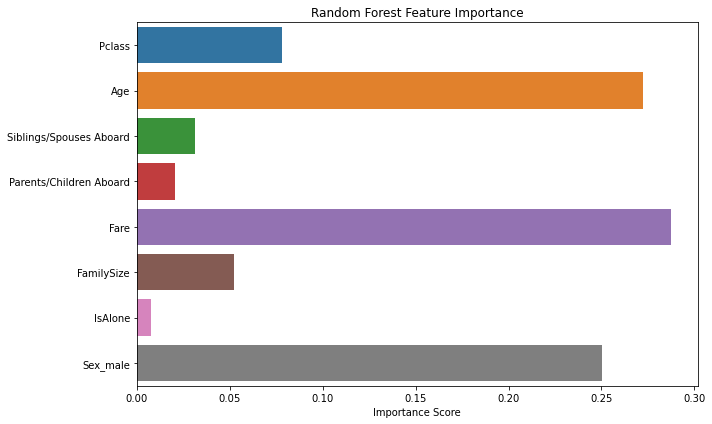

Pclass                             : 0.0782
Age                                : 0.2725
Siblings/Spouses Aboard            : 0.0313
Parents/Children Aboard            : 0.0207
Fare                               : 0.2873
FamilySize                         : 0.0520
IsAlone                            : 0.0077
Sex_male                           : 0.2503


In [12]:
# Extract feature importance from Random Forest
rf_model = models['Random Forest']

feature_names = numerical_features + list(
    rf_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

importances = rf_model.named_steps['classifier'].feature_importances_

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Print importance scores
for name, importance in zip(feature_names, importances):
    print(f"{name:35s}: {importance:.4f}")

In [16]:
print("=" * 45)
print("       MODEL PERFORMANCE SUMMARY")
print("=" * 45)
print(f"Logistic Regression Accuracy : 80.34% BEST")
print(f"Random Forest Accuracy       : 76.97%")
print()
print("=" * 45)
print("         KEY BUSINESS INSIGHTS")
print("=" * 45)
print("Top Survival Predictors:")
print("1. Fare paid       → 28.73% importance")
print("2. Age             → 27.25% importance")
print("3. Gender (Sex)    → 25.03% importance")
print()
print("Conclusions:")
print("Higher fare = better survival chances")
print("Age is critical survival factor")
print("Gender strongly affects survival")
print("Family size has minimal impact")
print("=" * 45)

       MODEL PERFORMANCE SUMMARY
Logistic Regression Accuracy : 80.34% BEST
Random Forest Accuracy       : 76.97%

         KEY BUSINESS INSIGHTS
Top Survival Predictors:
1. Fare paid       → 28.73% importance
2. Age             → 27.25% importance
3. Gender (Sex)    → 25.03% importance

Conclusions:
Higher fare = better survival chances
Age is critical survival factor
Gender strongly affects survival
Family size has minimal impact
